In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import chi2


np.random.seed(42)
gamma = 0.95

def norm_spread(k, n=1000):

    y = np.zeros(n)
    
    for i in range(n):
        uniform_samples = []
        for j in range(k):
            a = np.random.uniform(-5, 0)
            b = np.random.uniform(0, 5)
            sample = np.random.uniform(a, b)
            uniform_samples.append(sample)
        
        y[i] = np.sum(uniform_samples)
    
    return y

k = 25
n = 1000
normal_sample = norm_spread(k, n)

for i in range(n):
    normal_sample[i] += abs(min(normal_sample)) + 1

fitted_data, fitted_lambda = stats.boxcox(normal_sample)

print(fitted_lambda)

1.1560621952179906


РЕЗУЛЬТАТЫ ДЛЯ НОРМАЛЬНОГО РАСПРЕДЕЛЕНИЯ (ЦПТ)


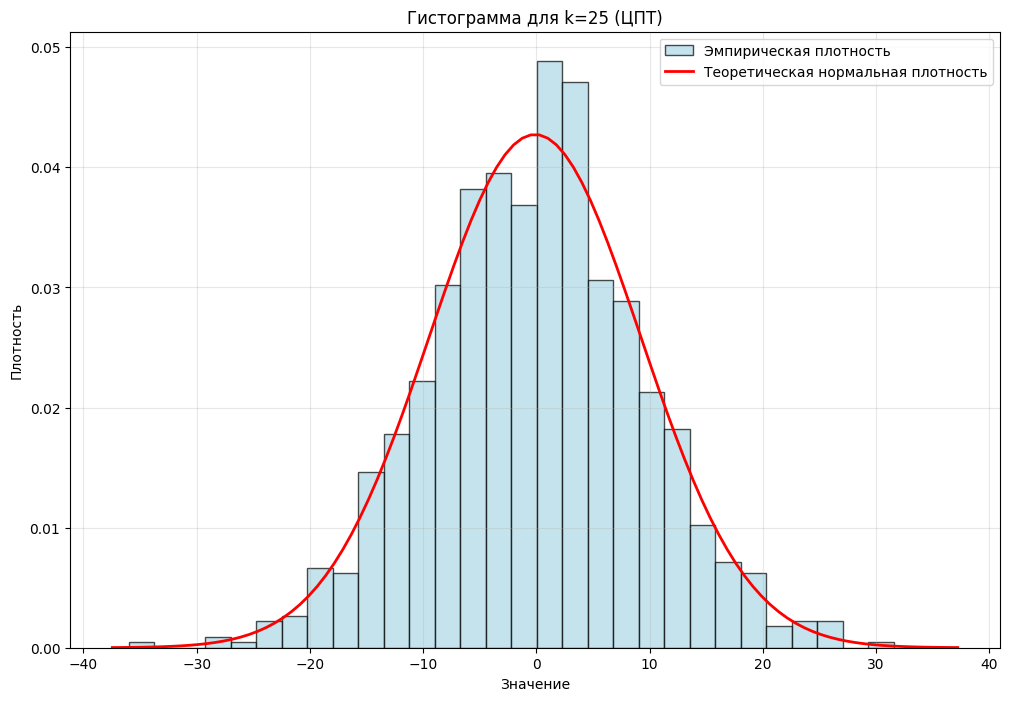

Оценки параметров: μ = -0.1139, σ = 9.3342
Число степеней свободы: 16
Критерий χ²: статистика = 8.7809, p-value = 0.9222


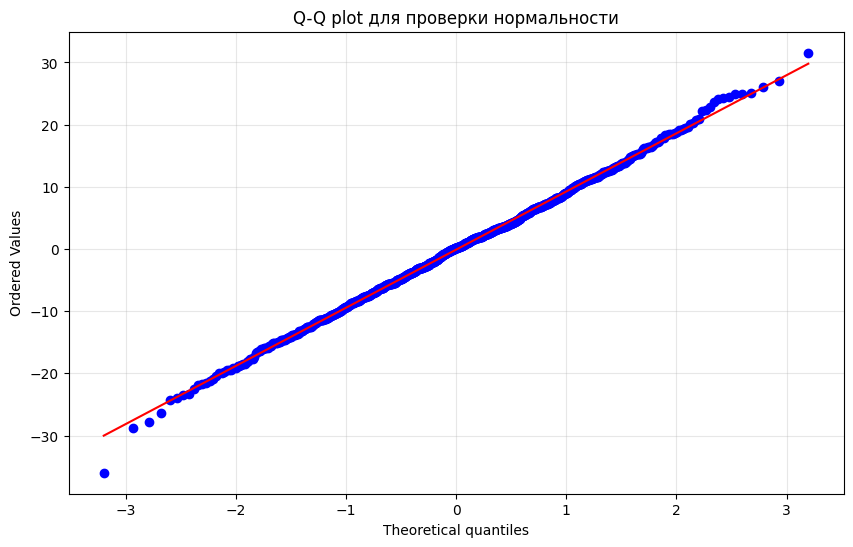

Метод анаморфоз: R² = 0.9987


In [24]:
from scipy.stats import probplot
def plt_hist(data, k, dist_name='normal'):
    plt.figure(figsize=(12, 8))
    plt.hist(data, bins=30, density=True, alpha=0.7, color='lightblue', edgecolor='black', label='Эмпирическая плотность')
    
    if dist_name == 'normal':
        mu = np.mean(data)
        sigma = np.std(data)
        x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
        theoretical = stats.norm.pdf(x, mu, sigma)
        plt.plot(x, theoretical, 'r-', linewidth=2, label='Теоретическая нормальная плотность')
    
    plt.title(f'Гистограмма для k={k} (ЦПТ)')
    plt.xlabel('Значение')
    plt.ylabel('Плотность')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return mu, sigma

def chi2_test(data, dist='norm', df_adjust=0):
    hist, bin_edges = np.histogram(data, bins='auto')
    
    if dist == 'norm':
        mu = np.mean(data)
        sigma = np.std(data)
        cdf_values = stats.norm.cdf(bin_edges, mu, sigma)
    elif dist == 'f':
        df1, df2 = 5, 10
        cdf_values = stats.f.cdf(bin_edges, df1, df2)
    elif dist == 't':
        df = len(data) - 1
        cdf_values = stats.t.cdf(bin_edges, df)
    
    expected = n * np.diff(cdf_values)
    mask = expected >= 5
    observed = hist[mask]
    expected = expected[mask]
    chi2_stat = np.sum((observed - expected)**2 / expected)
    df = len(observed) - 1 - df_adjust
    p_value = 1 - chi2.cdf(chi2_stat, df)
    
    return chi2_stat, p_value, df

def anamorphosis_test(data):
    plt.figure(figsize=(10, 6))
    probplot(data, dist="norm", plot=plt)
    plt.title('Q-Q plot для проверки нормальности')
    plt.grid(True, alpha=0.3)
    plt.show()

    _, (slope, intercept, r) = probplot(data, dist="norm", fit=True)
    return r**2

print("=" * 60)
print("РЕЗУЛЬТАТЫ ДЛЯ НОРМАЛЬНОГО РАСПРЕДЕЛЕНИЯ (ЦПТ)")
print("=" * 60)

mu, sigma = plt_hist(normal_sample, k)
print(f"Оценки параметров: μ = {mu:.4f}, σ = {sigma:.4f}")

chi2_stat, p_value, df = chi2_test(normal_sample, dist='norm', df_adjust=2)
print(f'Число степеней свободы: {df}')
print(f"Критерий χ²: статистика = {chi2_stat:.4f}, p-value = {p_value:.4f}")

r_squared = anamorphosis_test(normal_sample)
print(f"Метод анаморфоз: R² = {r_squared:.4f}")

In [40]:
print("\n" + "=" * 60)
print("ВЛИЯНИЕ k НА КАЧЕСТВО ГЕНЕРАЦИИ")
print("=" * 60)

for k in [2, 20, 30]:
    p_values = []
    for test in range(3):
        data = norm_spread(k, n)
        _, p_value, _ = chi2_test(data, dist='norm', df_adjust=2)
        p_values.append(p_value)
    
    avg_p = np.mean(p_values)
    print(f"k = {k}: средний p-value = {avg_p:.4f}")


ВЛИЯНИЕ k НА КАЧЕСТВО ГЕНЕРАЦИИ
k = 2: средний p-value = 0.1480
k = 20: средний p-value = 0.3359
k = 30: средний p-value = 0.5141


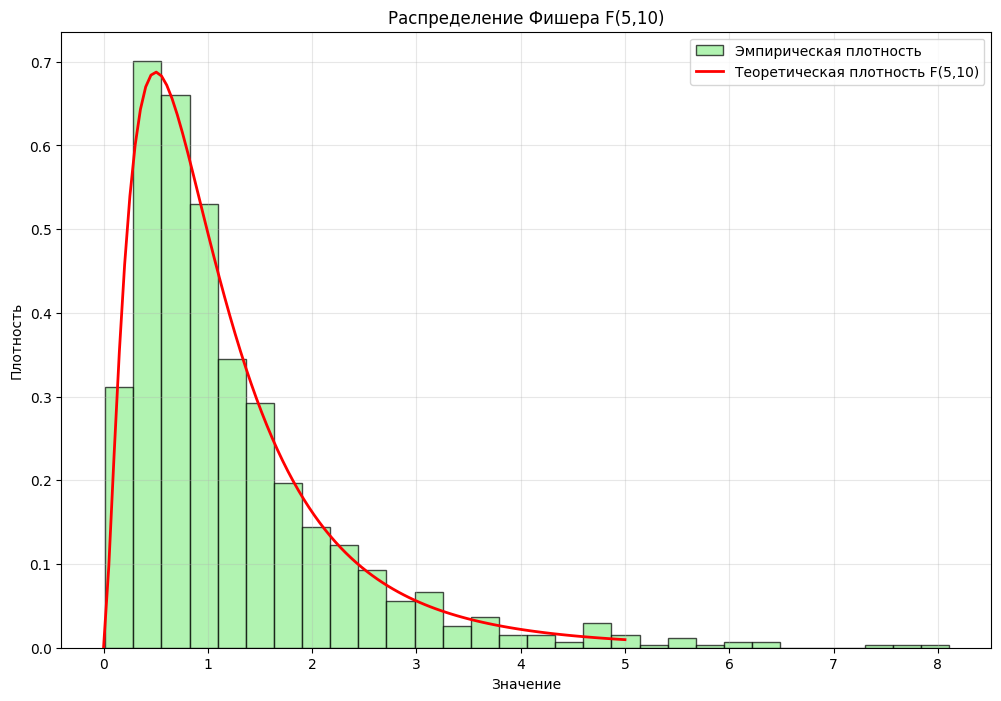


Распределение Фишера: χ² = 11.2402, p-value = 0.7354


In [ ]:
def fisher_spread(df1=5, df2=10, n=1000):
    y1 = np.random.chisquare(df1, n)
    y2 = np.random.chisquare(df2, n)
    f = (y1 / df1) / (y2 / df2)
    return f

f_sample = fisher_spread(5, 10, n)

plt.figure(figsize=(12, 8))
hist, bins, _ = plt.hist(f_sample, bins=30, density=True, alpha=0.7, color='lightgreen', edgecolor='black', label='Эмпирическая плотность')

x = np.linspace(0, 5, 100)
theor_f = stats.f.pdf(x, 5, 10)
plt.plot(x, theor_f, 'r-', linewidth=2, label='Теоретическая плотность F(5,10)')

plt.title('Распределение Фишера F(5,10)')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

chi2_stat_f, p_value_f, df_f = chi2_test(f_sample, dist='f', df_adjust=2)
print(f"\nРаспределение Фишера: χ² = {chi2_stat_f:.4f}, p-value = {p_value_f:.4f}")


РЕЗУЛЬТАТЫ ДЛЯ t-РАСПРЕДЕЛЕНИЯ СТЬЮДЕНТА


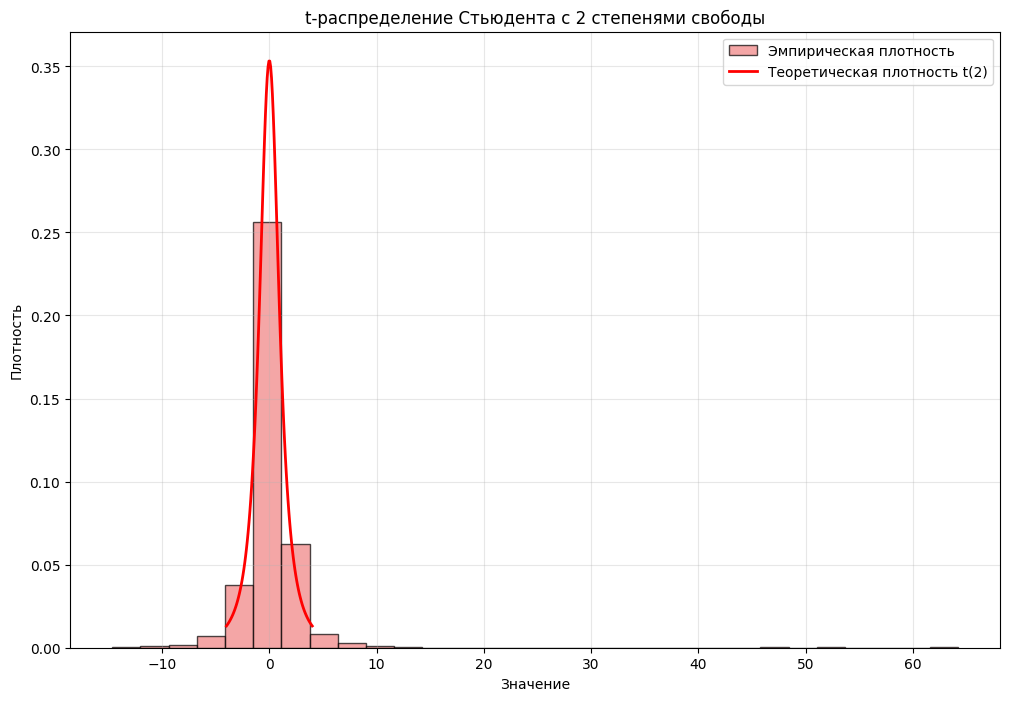

k = 2: χ² = 58.4102, p-value = 0.0000


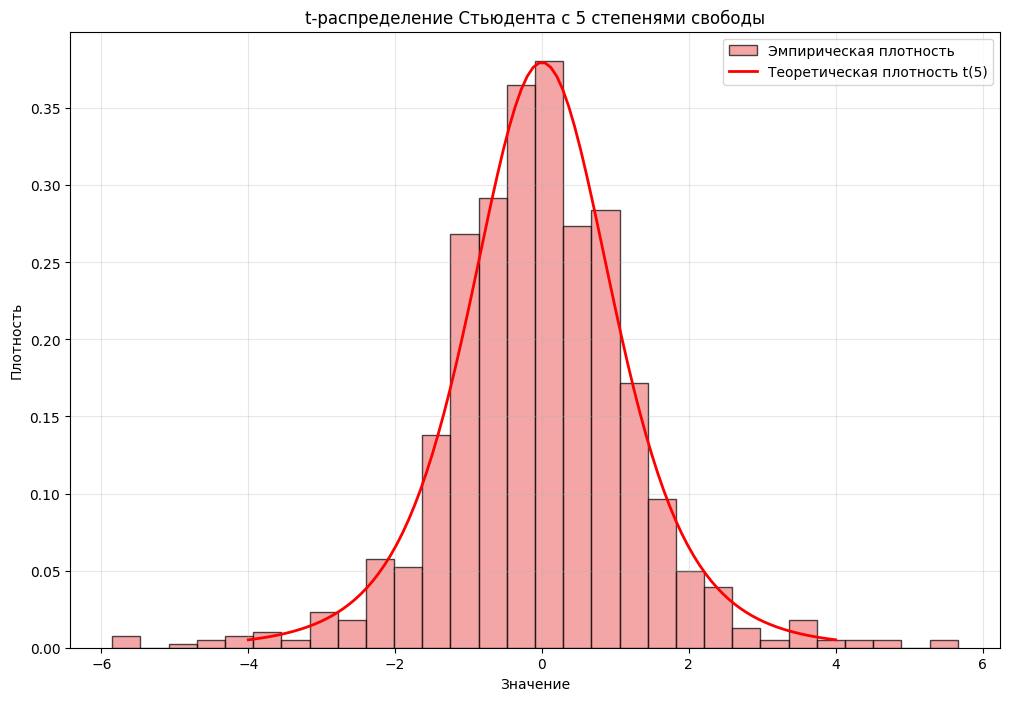

k = 5: χ² = 25.9166, p-value = 0.0265


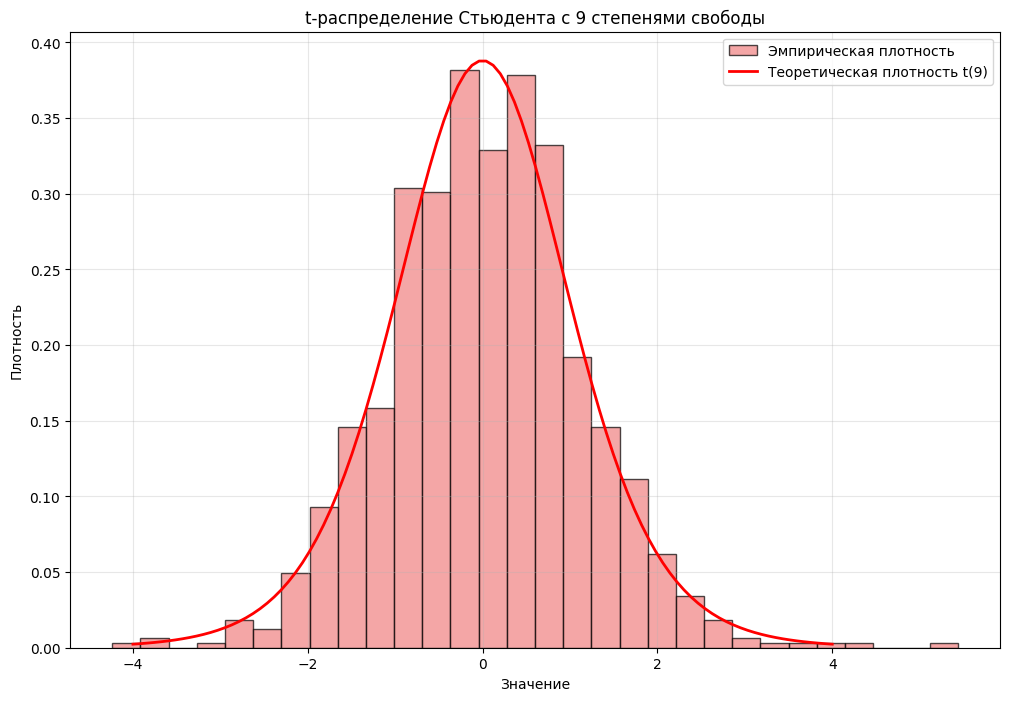

k = 9: χ² = 20.4108, p-value = 0.1567


In [51]:
def t_spread(k, n=1000):
    t = np.zeros(n)
    
    for i in range(n):
        y = np.random.standard_normal(k + 1)
        y0 = y[0]
        Y_rest = y[1:]
        t[i] = y0 / np.sqrt(np.sum(Y_rest**2) / k)
    
    return t

t_samples = {}
k_t_values = [2, 5, 9]

for k in k_t_values:
    t_samples[k] = t_spread(k, n)

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ ДЛЯ t-РАСПРЕДЕЛЕНИЯ СТЬЮДЕНТА")
print("=" * 60)

for k in k_t_values:
    data = t_samples[k]
    
    plt.figure(figsize=(12, 8))
    hist, bins, _ = plt.hist(data, bins=30, density=True, alpha=0.7, color='lightcoral', edgecolor='black', label='Эмпирическая плотность')
    
    x = np.linspace(-4, 4, 100)
    theor_t = stats.t.pdf(x, k)
    plt.plot(x, theor_t, 'r-', linewidth=2, label=f'Теоретическая плотность t({k})')
    
    plt.title(f't-распределение Стьюдента с {k} степенями свободы')
    plt.xlabel('Значение')
    plt.ylabel('Плотность')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    chi2_stat_t, p_value_t, df_t = chi2_test(data, dist='t', df_adjust=2)
    print(f"k = {k}: χ² = {chi2_stat_t:.4f}, p-value = {p_value_t:.4f}")